<a href="https://colab.research.google.com/github/myself-moons/CourseSense/blob/main/NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
CourseSense — Dataset Build & Text Preprocessing (Colab-ready)
================================================================
Sequential Student Interaction Modeling with GRU Networks
Dataset: ASSISTments 2009-2010 Skill-Builder data

Run this top to bottom in Google Colab. It will:
  1. Download the full ASSISTments 2009-2010 dataset (~525k rows) from GitHub
  2. Filter + sample it down to a manageable, GRU-friendly sequential dataset
     (~15,000 interaction rows, keeping each student's full sequence intact)
  3. Save the BEFORE file (raw sampled data)
  4. Apply text preprocessing to the `skill_name` field (this is our NLP step —
     skill names are short text like "Addition and Subtraction Fractions" that
     BoW/TF-IDF/Word2Vec can meaningfully be built on top of, later)
  5. Save the AFTER file (with a new `clean_skill_name` column)

Why this dataset fits the project title:
  Each row = one student's attempt at one skill, in chronological order
  (`order_id`). A GRU can read a student's sequence of attempts and predict
  whether they'll get the NEXT one right — this is the actual mechanism
  behind "personalized learning recommendation": recommend what a student
  should practice next, based on a model of their current mastery.
"""

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# STEP 0 — Setup
# ------------------------------------------------------------------
# !pip install nltk -q   # uncomment if nltk isn't already available in your Colab runtime

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------------
# STEP 1 — Download the full dataset
# ------------------------------------------------------------------
DATA_URL = "https://raw.githubusercontent.com/GaoSida/DKT/master/Assistments/skill_builder_data.csv"

print("Downloading dataset...")
df = pd.read_csv(DATA_URL, encoding="ISO-8859-1", low_memory=False)
print(f"Full dataset shape: {df.shape}")

# Keep only the columns relevant to sequential modeling + the text field for NLP
KEEP_COLS = [
    "order_id", "assignment_id", "user_id", "problem_id", "skill_id", "skill_name",
    "correct", "attempt_count", "hint_count", "hint_total", "ms_first_response", "overlap_time",
]
df = df[KEEP_COLS]

# Drop rows with no skill_name (no text to work with) or no skill_id
df = df.dropna(subset=["skill_name", "skill_id"]).reset_index(drop=True)
print(f"After dropping rows with missing skill_name/skill_id: {df.shape}")
print(f"Unique students: {df['user_id'].nunique()} | Unique skills: {df['skill_name'].nunique()}")

# ------------------------------------------------------------------
# STEP 2 — Sample down to ~15,000 rows, keeping full student sequences intact
# ------------------------------------------------------------------
# We must never split a student's sequence — a GRU needs each student's
# interactions to stay complete and in order. So we sample whole students,
# not random rows.

counts = df.groupby("user_id").size()

# Keep students with a reasonable sequence length: long enough to be a real
# sequence, short enough that no single student dominates the sample
MIN_LEN, MAX_LEN = 15, 120
eligible_students = counts[(counts >= MIN_LEN) & (counts <= MAX_LEN)].index.to_numpy().copy()

rng = np.random.default_rng(SEED)
rng.shuffle(eligible_students)

TARGET_ROWS = 15000
chosen, total = [], 0
for sid in eligible_students:
    n = counts[sid]
    if total + n > TARGET_ROWS + 1000:   # don't overshoot by too much
        continue
    chosen.append(sid)
    total += n
    if total >= TARGET_ROWS:
        break

print(f"\nChosen students: {len(chosen)} | Total interaction rows: {total}")

sample = df[df["user_id"].isin(chosen)].copy()
sample = sample.sort_values(["user_id", "order_id"]).reset_index(drop=True)  # true chronological order

print(f"Final sample shape: {sample.shape}")
print(f"Students: {sample['user_id'].nunique()} | Unique skills: {sample['skill_name'].nunique()}")
print(f"Overall correct rate: {sample['correct'].mean():.3f}")
print("\nInteractions-per-student summary:")
print(sample.groupby("user_id").size().describe())

# ------------------------------------------------------------------
# STEP 3 — Save the BEFORE file (raw sampled data)
# ------------------------------------------------------------------
sample.to_csv("assistments_sample_BEFORE.csv", index=False)
print("\nSaved assistments_sample_BEFORE.csv")

# ------------------------------------------------------------------
# STEP 4 — Text preprocessing on skill_name
# ------------------------------------------------------------------
# Skill names are short phrases like "Addition and Subtraction Fractions".
# We clean them the same way we'd clean any text field, so that later
# feature engineering (BoW / TF-IDF / Word2Vec) works on a clean vocabulary
# instead of raw, inconsistent strings.
#
#   1. Lowercase              -> case-insensitive matching
#   2. Strip non-alphabetic   -> remove stray punctuation/numbers
#   3. Tokenize               -> split into individual words
#   4. Remove stopwords       -> drop "and", "of", etc. (no signal, wastes vocabulary)
#   5. Lemmatize (noun form)  -> "Fractions" -> "fraction", so plural/singular
#                                 forms of the same skill collapse together

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_skill_name(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t, pos="n") for t in tokens]
    return " ".join(tokens) if tokens else text  # fallback: keep original if everything got stripped


after = sample.copy()
after["clean_skill_name"] = after["skill_name"].apply(clean_skill_name)

print(f"\nUnique raw skill_name: {sample['skill_name'].nunique()}")
print(f"Unique clean_skill_name: {after['clean_skill_name'].nunique()}")
print("\nSample before -> after:")
print(after[["skill_name", "clean_skill_name"]].drop_duplicates().head(15).to_string())

# ------------------------------------------------------------------
# STEP 5 — Save the AFTER file
# ------------------------------------------------------------------
after.to_csv("assistments_sample_AFTER.csv", index=False)
print("\nSaved assistments_sample_AFTER.csv")
print(f"Final shape: {after.shape}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Full dataset shape: (525534, 30)
After dropping rows with missing skill_name/skill_id: (446844, 12)
Unique students: 4151 | Unique skills: 110

Chosen students: 344 | Total interaction rows: 15061
Final sample shape: (15061, 12)
Students: 344 | Unique skills: 94
Overall correct rate: 0.614

Interactions-per-student summary:
count    344.000000
mean      43.781977
std       27.888504
min       15.000000
25%       21.750000
50%       34.000000
75%       59.250000
max      120.000000
dtype: float64

Saved assistments_sample_BEFORE.csv

Unique raw skill_name: 94
Unique clean_skill_name: 93

Sample before -> after:
                                    skill_name                       clean_skill_name
0                                        Table                                  table
1                                         Mean                                   mean
9                                       Median                                 median
14        Multiplication and Division 

Shape: (15061, 13)
order_id               int64
assignment_id          int64
user_id                int64
problem_id             int64
skill_id             float64
skill_name            object
correct                int64
attempt_count          int64
hint_count             int64
hint_total             int64
ms_first_response      int64
overlap_time           int64
clean_skill_name      object
dtype: object
Missing values per column:
 order_id             0
assignment_id        0
user_id              0
problem_id           0
skill_id             0
skill_name           0
correct              0
attempt_count        0
hint_count           0
hint_total           0
ms_first_response    0
overlap_time         0
clean_skill_name     0
dtype: int64

Unique students: 344
Unique skills: 93
correct
0    5816
1    9245
Name: count, dtype: int64
Correct rate: 0.614


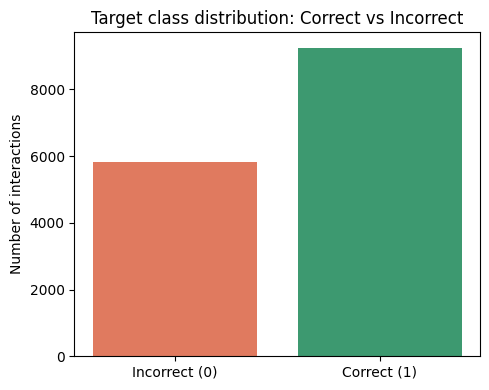

count    344.000000
mean      43.781977
std       27.888504
min       15.000000
25%       21.750000
50%       34.000000
75%       59.250000
max      120.000000
dtype: float64
15-24     111
25-34      63
35-44      46
45-59      38
60-79      36
80-120     50
Name: count, dtype: int64


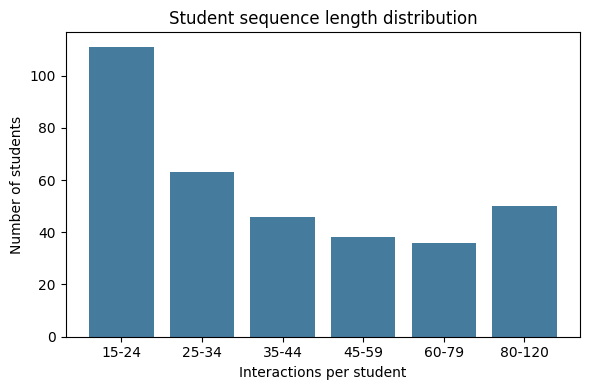

clean_skill_name
conversion fraction decimal percent    1600
equation solving two fewer step        1175
addition subtraction integer           1078
addition subtraction fraction           833
absolute value                          564
proportion                              498
ordering fraction                       485
percent                                 479
multiplication division integer         476
probability single event                463
Name: count, dtype: int64


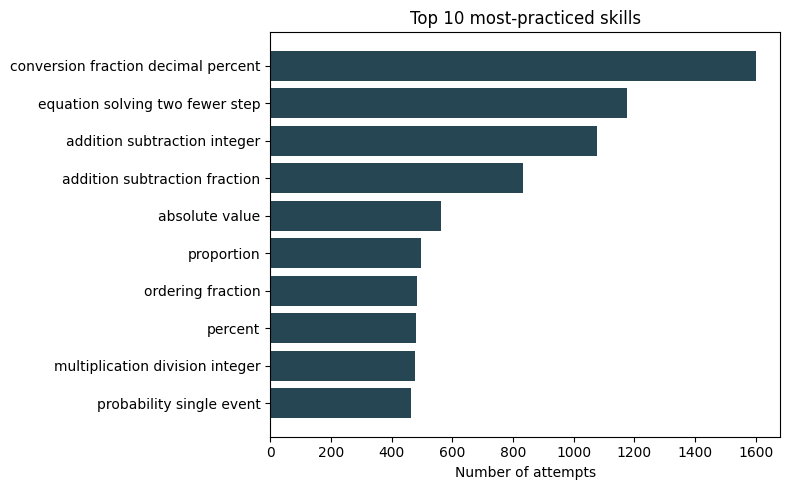

Hardest 5 skills:
 clean_skill_name
finding percent                          0.358362
equivalent fraction                      0.375000
addition subtraction positive decimal    0.376506
unit rate                                0.412903
probability two distinct event           0.442478
Name: correct, dtype: float64

Easiest 5 skills:
 clean_skill_name
box whisker                        0.776256
multiplication division integer    0.789916
ordering fraction                  0.812371
ordering integer                   0.813559
mode                               0.866667
Name: correct, dtype: float64


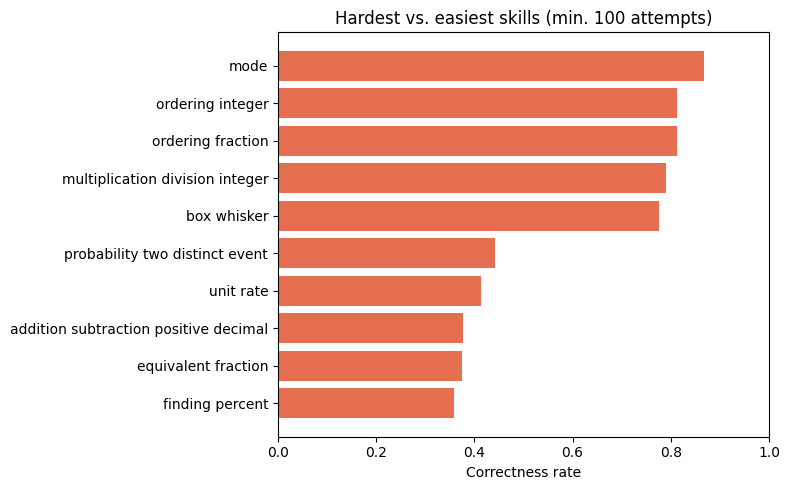

                 mean  count
opportunity                 
1            0.524476   2288
2            0.634066   1820
3            0.634910   1501
4            0.664157   1328
5            0.630551   1126
6            0.614799    919
7            0.624352    772
8            0.639937    636
9            0.632727    550
10           0.616495    485


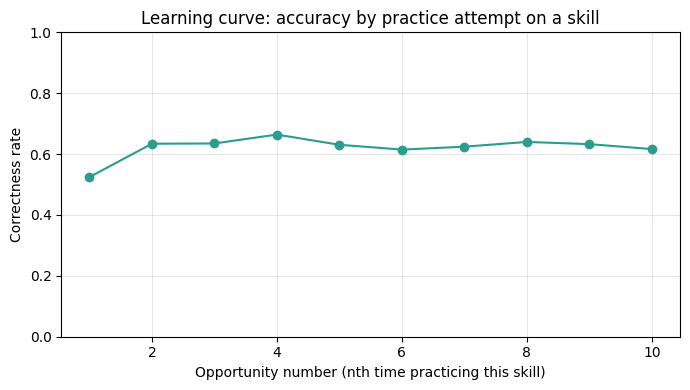

Attempt count distribution:
 attempt_count
0      430
1    11655
2     1476
3      610
4      366
5      153
6       94
7       50
8       32
9       23
Name: count, dtype: int64

Mean attempt_count: 1.709

% interactions with >=1 hint used: 0.172
Correctness rate, hint used vs not:
 hint_count
False    0.741359
True     0.000386
Name: correct, dtype: float64
Most common words across skill occurrences (frequency-weighted):
  fraction        3501
  addition        2496
  subtraction     2481
  percent         2374
  decimal         2342
  two             1708
  integer         1672
  conversion      1632
  equation        1582
  solving         1462
  step            1369
  fewer           1175
  ordering        976
  positive        893
  probability     803


In [ ]:
# %% [markdown]
# # CourseSense — Exploratory Data Analysis
# Dataset: `assistments_sample_AFTER.csv` (15,061 interactions, 344 students, 94 skills)
#
# Run each `# %%` block as its own cell in Colab / Jupyter.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("assistments_sample_AFTER.csv")
print("Shape:", df.shape)
print(df.dtypes)

# %% [markdown]
# ## 1. Basic integrity checks

# %%
print("Missing values per column:\n", df.isna().sum())
print("\nUnique students:", df["user_id"].nunique())
print("Unique skills:", df["clean_skill_name"].nunique())

# %% [markdown]
# ## 2. Target distribution — correct vs. incorrect

# %%
target_counts = df["correct"].value_counts().sort_index()
print(target_counts)
print("Correct rate:", df["correct"].mean().round(3))

plt.figure(figsize=(5, 4))
plt.bar(["Incorrect (0)", "Correct (1)"], target_counts.values, color=["#e07a5f", "#3d9970"])
plt.title("Target class distribution: Correct vs Incorrect")
plt.ylabel("Number of interactions")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=150)
plt.show()

# %% [markdown]
# ## 3. Sequence length per student
# A GRU needs to see real variation in sequence length — this checks that we have it.

# %%
seq_len = df.groupby("user_id").size()
print(seq_len.describe())

bins = [15, 25, 35, 45, 60, 80, 121]
labels = ["15-24", "25-34", "35-44", "45-59", "60-79", "80-120"]
bucket = pd.cut(seq_len, bins=bins, labels=labels, right=False, include_lowest=True)
bucket_counts = bucket.value_counts().reindex(labels)
print(bucket_counts)

plt.figure(figsize=(6, 4))
plt.bar(bucket_counts.index, bucket_counts.values, color="#457b9d")
plt.title("Student sequence length distribution")
plt.xlabel("Interactions per student")
plt.ylabel("Number of students")
plt.tight_layout()
plt.savefig("eda_sequence_length.png", dpi=150)
plt.show()

# %% [markdown]
# ## 4. Skill frequency — which skills are practiced most?

# %%
top_skills = df["clean_skill_name"].value_counts().head(10)
print(top_skills)

plt.figure(figsize=(8, 5))
plt.barh(top_skills.index[::-1], top_skills.values[::-1], color="#264653")
plt.title("Top 10 most-practiced skills")
plt.xlabel("Number of attempts")
plt.tight_layout()
plt.savefig("eda_top_skills.png", dpi=150)
plt.show()

# %% [markdown]
# ## 5. Correctness rate by skill (difficulty spread)
# Restricted to skills with >= 100 attempts so the rate is stable.

# %%
skill_counts = df["clean_skill_name"].value_counts()
frequent_skills = skill_counts[skill_counts >= 100].index
skill_acc = (
    df[df["clean_skill_name"].isin(frequent_skills)]
    .groupby("clean_skill_name")["correct"]
    .mean()
    .sort_values()
)

print("Hardest 5 skills:\n", skill_acc.head(5))
print("\nEasiest 5 skills:\n", skill_acc.tail(5))

hardest_easiest = pd.concat([skill_acc.head(5), skill_acc.tail(5)])
plt.figure(figsize=(8, 5))
plt.barh(hardest_easiest.index, hardest_easiest.values, color="#e76f51")
plt.title("Hardest vs. easiest skills (min. 100 attempts)")
plt.xlabel("Correctness rate")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("eda_skill_difficulty.png", dpi=150)
plt.show()

# %% [markdown]
# ## 6. Learning curve — does accuracy improve with practice?
# For each student-skill pair, number attempts in chronological order (1st time seeing
# the skill, 2nd time, ...), then average correctness at each opportunity number.

# %%
df_sorted = df.sort_values(["user_id", "clean_skill_name", "order_id"]).copy()
df_sorted["opportunity"] = df_sorted.groupby(["user_id", "clean_skill_name"]).cumcount() + 1

lc = df_sorted[df_sorted["opportunity"] <= 10].groupby("opportunity")["correct"].agg(["mean", "count"])
print(lc)

plt.figure(figsize=(7, 4))
plt.plot(lc.index, lc["mean"], marker="o", color="#2a9d8f")
plt.title("Learning curve: accuracy by practice attempt on a skill")
plt.xlabel("Opportunity number (nth time practicing this skill)")
plt.ylabel("Correctness rate")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("eda_learning_curve.png", dpi=150)
plt.show()

# %% [markdown]
# ## 7. Attempt count & hint usage
# Checking these because they're candidate engineered features — and because hint
# usage turns out to leak the answer (see findings below).

# %%
print("Attempt count distribution:\n", df["attempt_count"].value_counts().sort_index().head(10))
print("\nMean attempt_count:", df["attempt_count"].mean().round(3))

pct_hint = (df["hint_count"] > 0).mean()
print(f"\n% interactions with >=1 hint used: {pct_hint:.3f}")
print("Correctness rate, hint used vs not:\n", df.groupby(df["hint_count"] > 0)["correct"].mean())

# %% [markdown]
# ## 8. Skill-name vocabulary (from `clean_skill_name`)
# This is the text feature engineering will build on (BoW / TF-IDF / Word2Vec).

# %%
all_words_weighted = " ".join(df["clean_skill_name"]).split()
top_words = Counter(all_words_weighted).most_common(15)
print("Most common words across skill occurrences (frequency-weighted):")
for word, count in top_words:
    print(f"  {word:<15} {count}")

# %% [markdown]
# ## Findings & Next Steps
#
# **Dataset integrity:** 15,061 interactions, 344 students, 94 skills, zero missing
# values across all 13 columns.
#
# **Target balance:** 61.4% correct / 38.6% incorrect — moderately imbalanced but
# workable without resampling.
#
# **Sequence variation:** student sequences range from 15 to 120 interactions
# (median 34), giving the GRU real variety to learn from rather than a flat,
# uniform input length.
#
# **Skill frequency is long-tailed:** the top skill alone makes up ~10.6% of all
# rows; many of the 94 skills have far fewer examples, which limits how reliably
# we can model some individual skills in isolation.
#
# **Skill difficulty varies widely:** correctness rate ranges from 36% ("finding
# percent") to 87% ("mode") among skills with at least 100 attempts. This is a
# strong candidate feature — and something the GRU should be able to pick up
# implicitly through its skill embeddings.
#
# **A real learning-curve effect exists:** accuracy jumps from 52.4% on a
# student's first attempt at a skill to 63–66% on later attempts, then plateaus.
# This is direct evidence that a student's history on a skill is predictive of
# their future performance — the core premise behind "personalized learning
# recommendation."
#
# **Data leakage risk — `hint_count`:** interactions where a hint was used have a
# correctness rate of ~0.04%, vs. 74% with no hint. This isn't a "hints hurt
# learning" signal so much as hint requests and wrong answers being recorded
# together on the same attempt. `hint_count` should be excluded or carefully
# re-engineered (e.g. hint usage on *previous* attempts only) rather than fed in
# directly, or the model will just learn to detect hints.
#
# **`attempt_count` looks safer:** 77% of interactions were solved in a single
# attempt, with a long tail out to 9+ attempts — a reasonable engineered feature
# for the classical baselines.
#
# **Skill-name vocabulary:** dominated by math-topic words (fraction, addition,
# subtraction, percent, decimal, equation, probability) — a sensible, non-trivial
# vocabulary size for TF-IDF, though likely too small on its own for a strong
# Word2Vec model (worth using pretrained GloVe vectors instead, or treating
# Word2Vec as a smaller demonstration piece alongside TF-IDF).
#
# ### Next steps
# 1. **Feature engineering** — build the per-student skill-ID sequence for the
#    GRU (Embedding layer), and BoW/TF-IDF (+ optionally Word2Vec/GloVe) on
#    `clean_skill_name` for the classical baselines.
# 2. **Engineer safe features** — rolling per-student accuracy so far, opportunity
#    count per skill, skill difficulty (global correctness rate), attempt_count.
#    Exclude raw `hint_count` or lag it by one step.
# 3. **Train classical baselines** (Naive Bayes, Logistic Regression, Random
#    Forest, SVM, or XGBoost) on the engineered features to predict `correct`.
# 4. **Train the GRU** on the true chronological sequence per student to predict
#    the next interaction's correctness.
# 5. **Compare** classical baselines vs. GRU on Accuracy, Precision, Recall,
#    F1, Confusion Matrix, and ROC-AUC.

In [ ]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 23.8 MB/s eta 0:00:00


In [ ]:
"""
CourseSense — Feature Engineering (Colab-ready)
================================================================
Input : assistments_sample_AFTER.csv  (15,061 rows, from the preprocessing step)
Outputs:
  - engineered_features.csv   row-level features for the classical ML baselines
  - gru_sequences.npz         padded per-student sequences for the GRU
  - skill_vocab.json          skill-name -> integer index mapping

Feature choices are grounded in knowledge-tracing / educational-data-mining
literature (Performance Factor Analysis, IKT/EIKT, DKT-style input encoding) —
see the references noted inline below.
"""

import json
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

# !pip install gensim -q   # uncomment if gensim isn't already available in your Colab runtime

SEED = 42

# ------------------------------------------------------------------
# STEP 0 — Load
# ------------------------------------------------------------------
df = pd.read_csv("assistments_sample_AFTER.csv")
df = df.sort_values(["user_id", "order_id"]).reset_index(drop=True)
print("Loaded:", df.shape)

# ------------------------------------------------------------------
# STEP 1 — Row-level features for the classical ML baselines
# ------------------------------------------------------------------
# Feature families here follow Performance Factor Analysis (PFA — Pavlik et al.)
# and the "meaningful latent features" used in Interpretable Knowledge Tracing
# (Minn et al., IKT/EIKT): per-skill prior success/failure counts, skill
# difficulty, and student ability (rolling accuracy).

# 1a. Opportunity count: how many times has this student practiced this skill?
df["opportunity"] = df.groupby(["user_id", "clean_skill_name"]).cumcount() + 1

# 1b. PFA-style prior success/failure counts (shifted so the CURRENT row's
#     outcome is never counted in its own features — this avoids leakage)
df["_cum_correct"] = df.groupby(["user_id", "clean_skill_name"])["correct"].cumsum()
df["prior_success_count"] = df["_cum_correct"] - df["correct"]
df["prior_failure_count"] = (df["opportunity"] - 1) - df["prior_success_count"]

# 1c. Skill difficulty: leave-one-out global correctness rate for that skill
#     (leave-one-out so a skill's own current-row outcome doesn't leak into
#     its own difficulty estimate)
skill_sum = df.groupby("clean_skill_name")["correct"].transform("sum")
skill_cnt = df.groupby("clean_skill_name")["correct"].transform("count")
df["skill_difficulty"] = (skill_sum - df["correct"]) / (skill_cnt - 1)

# 1d. Student ability: expanding rolling accuracy, shifted by one row so the
#     current outcome isn't included in its own rolling average
df["_cum_correct_student"] = df.groupby("user_id")["correct"].cumsum()
df["student_interaction_number"] = df.groupby("user_id").cumcount() + 1
df["prior_student_correct"] = df["_cum_correct_student"] - df["correct"]
df["student_rolling_accuracy"] = df["prior_student_correct"] / (df["student_interaction_number"] - 1)
overall_mean = df["correct"].mean()
df["student_rolling_accuracy"] = df["student_rolling_accuracy"].fillna(overall_mean)  # first interaction has no history

# 1e. Timing features — legitimate contemporaneous behavioral signal
#     (used as prior_question_elapsed_time-style features in real KT systems,
#     e.g. the Riiid competition). Log-transformed since response times are
#     heavily right-skewed.
df["log_ms_first_response"] = np.log1p(df["ms_first_response"].clip(lower=0))
df["log_overlap_time"] = np.log1p(df["overlap_time"].clip(lower=0))

# ------------------------------------------------------------------
# IMPORTANT — features deliberately EXCLUDED, and why
# ------------------------------------------------------------------
# attempt_count and hint_count/hint_total are NOT included as predictive
# features. In this dataset, `correct` means "got it right on the FIRST
# attempt" — so attempt_count > 1 is near-tautological with correct = 0
# (verified: 79% correct when attempt_count == 1, under 2% for any higher
# value, 0% for 5+). hint_count shows the same pattern (0.04% correct when a
# hint was used vs. 74% when not). Both describe the outcome of the very
# interaction we're trying to predict, not information available beforehand
# — including them would make the "prediction" task trivial and meaningless.
df = df.drop(columns=["_cum_correct", "_cum_correct_student", "prior_student_correct",
                       "attempt_count", "hint_count", "hint_total"])

print("\nCorrelation of engineered features with target (correct):")
feat_cols = ["opportunity", "prior_success_count", "prior_failure_count", "skill_difficulty",
             "student_rolling_accuracy", "student_interaction_number",
             "log_ms_first_response", "log_overlap_time"]
print(df[feat_cols + ["correct"]].corr()["correct"].sort_values(ascending=False))

# ------------------------------------------------------------------
# STEP 2 — Text feature engineering on clean_skill_name
# ------------------------------------------------------------------
# Bag of Words
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(df["clean_skill_name"])
print(f"\nBoW matrix: {bow_matrix.shape}, vocab size {len(bow_vec.vocabulary_)}")

# TF-IDF
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(df["clean_skill_name"])
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

# Word2Vec — trained on the skill-name corpus.
# CAVEAT: skill names give us only ~128 unique vocabulary words across 93
# skills. This is too small a corpus for Word2Vec to learn strong semantic
# embeddings on its own (nearest-neighbor results below are plausible but
# noisy). For production use, pretrained GloVe vectors for these words would
# likely be more reliable; Word2Vec is included here mainly to demonstrate
# the technique as required, with BoW/TF-IDF doing the heavier lifting.
sentences = [s.split() for s in df["clean_skill_name"]]
w2v = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=2, seed=SEED, epochs=50)
print(f"\nWord2Vec vocabulary size: {len(w2v.wv.key_to_index)}")
for word in ["fraction", "addition", "equation"]:
    if word in w2v.wv:
        print(f"  Nearest to '{word}':", w2v.wv.most_similar(word, topn=5))

# Save engineered row-level features (classical ML baselines will load this directly)
df.to_csv("engineered_features.csv", index=False)
print(f"\nSaved engineered_features.csv, shape {df.shape}")

# ------------------------------------------------------------------
# STEP 3 — Build sequences for the GRU (classic DKT-style input encoding)
# ------------------------------------------------------------------
# Each student's history becomes one padded sequence. At each timestep we
# encode the (skill, correctness) pair as a single integer:
#   interaction_id = skill_idx              if incorrect
#   interaction_id = skill_idx + num_skills if correct
# This integer feeds an Embedding layer of vocab size 2*num_skills — the
# same input scheme used in the original Deep Knowledge Tracing paper
# (Piech et al., 2015).

skills = sorted(df["clean_skill_name"].unique())
skill_to_idx = {s: i for i, s in enumerate(skills)}
num_skills = len(skills)
df["skill_idx"] = df["clean_skill_name"].map(skill_to_idx)
df["interaction_id"] = df["skill_idx"] + df["correct"] * num_skills

sequences = df.groupby("user_id").agg(
    skill_seq=("skill_idx", list),
    correct_seq=("correct", list),
    interaction_seq=("interaction_id", list),
).reset_index()
sequences["seq_len"] = sequences["skill_seq"].apply(len)

max_len = sequences["seq_len"].max()
n_students = len(sequences)
print(f"\nStudents: {n_students} | num_skills: {num_skills} | max_len: {max_len}")

PAD_VALUE = -1
skill_arr = np.full((n_students, max_len), PAD_VALUE, dtype=np.int32)
correct_arr = np.full((n_students, max_len), PAD_VALUE, dtype=np.int32)
interaction_arr = np.full((n_students, max_len), 2 * num_skills, dtype=np.int32)  # dedicated pad token
seq_lengths = np.zeros(n_students, dtype=np.int32)

for i, row in sequences.iterrows():
    L = row["seq_len"]
    skill_arr[i, :L] = row["skill_seq"]
    correct_arr[i, :L] = row["correct_seq"]
    interaction_arr[i, :L] = row["interaction_seq"]
    seq_lengths[i] = L

print("Padded array shapes:", skill_arr.shape, correct_arr.shape, interaction_arr.shape, seq_lengths.shape)
print("\nExample (student 0), first 10 timesteps:")
print("  skill_idx:  ", skill_arr[0, :10])
print("  correct:    ", correct_arr[0, :10])
print("  interaction:", interaction_arr[0, :10])
print("  true length:", seq_lengths[0])

np.savez("gru_sequences.npz",
         skill_arr=skill_arr, correct_arr=correct_arr,
         interaction_arr=interaction_arr, seq_lengths=seq_lengths,
         num_skills=num_skills)
print("\nSaved gru_sequences.npz")

with open("skill_vocab.json", "w") as f:
    json.dump(skill_to_idx, f, indent=2)
print("Saved skill_vocab.json")

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------
print("""
Done. Three artifacts produced:
  engineered_features.csv  -> row-level features for classical ML baselines
                               (Naive Bayes, Logistic Regression, Random
                               Forest, SVM, XGBoost) predicting `correct`
  gru_sequences.npz         -> padded per-student interaction sequences,
                               ready for an Embedding -> GRU -> Dense model
  skill_vocab.json          -> skill name <-> integer index mapping
""")

Loaded: (15061, 13)

Correlation of engineered features with target (correct):
correct                       1.000000
student_rolling_accuracy      0.308649
skill_difficulty              0.231002
prior_success_count           0.132988
student_interaction_number    0.031514
opportunity                   0.022653
log_ms_first_response        -0.044200
prior_failure_count          -0.117773
log_overlap_time             -0.308684
Name: correct, dtype: float64

BoW matrix: (15061, 128), vocab size 128
TF-IDF matrix: (15061, 128)

Word2Vec vocabulary size: 128
  Nearest to 'fraction': [('positive', 0.6647670269012451), ('integer', 0.6273355484008789), ('percent', 0.6049930453300476), ('decimal', 0.5017213821411133), ('discount', 0.5001677870750427)]
  Nearest to 'addition': [('ordering', 0.6731231212615967), ('division', 0.5252763032913208), ('subtraction', 0.5200693011283875), ('whole', 0.5082603693008423), ('multiplication', 0.507922351360321)]
  Nearest to 'equation': [('algebraic', 0.613

# GRU

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('assistments_sample_AFTER.csv')
df = df.sort_values(['user_id', 'order_id']).reset_index(drop=True)

skills = sorted(df['clean_skill_name'].unique())
skill_to_idx = {s: i for i, s in enumerate(skills)}
num_skills = len(skills)
df['skill_idx'] = df['clean_skill_name'].map(skill_to_idx)
df['interaction_id'] = df['skill_idx'] + df['correct'] * num_skills

sequences = df.groupby('user_id').agg(
    skill_seq=('skill_idx', list),
    correct_seq=('correct', list),
    interaction_seq=('interaction_id', list),
).reset_index()
sequences['seq_len'] = sequences['skill_seq'].apply(len)

max_len = sequences['seq_len'].max()
n_students = len(sequences)
student_ids = sequences['user_id'].values

PAD_VALUE = -1
skill_arr = np.full((n_students, max_len), PAD_VALUE, dtype=np.int32)
correct_arr = np.full((n_students, max_len), PAD_VALUE, dtype=np.int32)
interaction_arr = np.full((n_students, max_len), 2*num_skills, dtype=np.int32)
seq_lengths = np.zeros(n_students, dtype=np.int32)

for i, row in sequences.iterrows():
    L = row['seq_len']
    skill_arr[i, :L] = row['skill_seq']
    correct_arr[i, :L] = row['correct_seq']
    interaction_arr[i, :L] = row['interaction_seq']
    seq_lengths[i] = L

# ---- Use the EXACT SAME split as the classical baselines ----
eng_df = pd.read_csv('engineered_features.csv')
rng = np.random.default_rng(42)
students_order = eng_df['user_id'].unique()
rng.shuffle(students_order)
n_test = int(len(students_order) * 0.2)
test_students = set(students_order[:n_test])
train_students = set(students_order[n_test:])

train_mask = np.isin(student_ids, list(train_students))
test_mask = np.isin(student_ids, list(test_students))
print("Train students in GRU data:", train_mask.sum(), "| Test students:", test_mask.sum())
print("num_skills:", num_skills, "max_len:", max_len)

np.savez('gru_sequences_v2.npz',
         skill_arr=skill_arr, correct_arr=correct_arr, interaction_arr=interaction_arr,
         seq_lengths=seq_lengths, student_ids=student_ids,
         train_mask=train_mask, test_mask=test_mask, num_skills=num_skills)
print("Saved gru_sequences_v2.npz")

Train students in GRU data: 276 | Test students: 68
num_skills: 93 max_len: 120
Saved gru_sequences_v2.npz


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

data = np.load('gru_sequences_v2.npz')
skill_arr = data['skill_arr']
correct_arr = data['correct_arr']
interaction_arr = data['interaction_arr']
train_mask = data['train_mask']
test_mask = data['test_mask']
num_skills = int(data['num_skills'])

X = interaction_arr[:, :-1]
target_skill = skill_arr[:, 1:]
target_correct = correct_arr[:, 1:].astype(np.float32)   # padding stays -1.0, used by custom loss
T_minus_1 = X.shape[1]

target_skill_safe = np.clip(target_skill, 0, num_skills - 1)
target_skill_onehot = tf.keras.utils.to_categorical(target_skill_safe, num_classes=num_skills).astype(np.float32)

X_train, X_test = X[train_mask], X[test_mask]
skill_oh_train, skill_oh_test = target_skill_onehot[train_mask], target_skill_onehot[test_mask]
y_train, y_test = target_correct[train_mask], target_correct[test_mask]

print("Train:", X_train.shape, "Test:", X_test.shape)

VOCAB_SIZE = 2 * num_skills + 1
EMBED_DIM = 32
GRU_UNITS = 64

interaction_input = layers.Input(shape=(T_minus_1,), name='interaction_seq')
skill_onehot_input = layers.Input(shape=(T_minus_1, num_skills), name='target_skill_onehot')

x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)(interaction_input)
x = layers.GRU(GRU_UNITS, return_sequences=True, dropout=0.2)(x)
per_skill_prob = layers.Dense(num_skills, activation='sigmoid')(x)

selected = layers.Multiply()([per_skill_prob, skill_onehot_input])
output = layers.Lambda(lambda t: tf.reduce_sum(t, axis=-1), output_shape=(T_minus_1,))(selected)

model = keras.Model(inputs=[interaction_input, skill_onehot_input], outputs=output)

def masked_bce_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, -1.0), tf.float32)
    y_true_safe = tf.clip_by_value(y_true, 0.0, 1.0)
    eps = 1e-7
    y_pred_c = tf.clip_by_value(y_pred, eps, 1 - eps)
    bce = -(y_true_safe * tf.math.log(y_pred_c) + (1 - y_true_safe) * tf.math.log(1 - y_pred_c))
    bce = bce * mask
    return tf.reduce_sum(bce) / (tf.reduce_sum(mask) + eps)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=masked_bce_loss)
model.summary()

history = model.fit(
    [X_train, skill_oh_train], y_train,
    validation_data=([X_test, skill_oh_test], y_test),
    epochs=30, batch_size=32, verbose=2
)

model.save('gru_model.keras')
np.savez('/gru_history.npz', loss=history.history['loss'], val_loss=history.history['val_loss'])
print("\nSaved model and history")

Train: (276, 119) Test: (68, 119)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interaction_seq     │ (None, 119)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 119, 32)   │      5,984 │ interaction_seq[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 119, 64)   │     18,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 119, 93)   │      6,045 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_skill_onehot │ (None, 119, 93)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 119, 93)   │          0 │ dense[0][0],      │
│                     │                   │            │ target_skill_one… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 119)       │          0 │ multiply[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,845 (120.49 KB)

 Trainable params: 30,845 (120.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
9/9 - 10s - 1s/step - loss: 0.6894 - val_loss: 0.6847
Epoch 2/30
9/9 - 2s - 239ms/step - loss: 0.6777 - val_loss: 0.6735
Epoch 3/30
9/9 - 3s - 290ms/step - loss: 0.6622 - val_loss: 0.6588
Epoch 4/30
9/9 - 2s - 275ms/step - loss: 0.6397 - val_loss: 0.6508
Epoch 5/30
9/9 - 2s - 255ms/step - loss: 0.6224 - val_loss: 0.6297
Epoch 6/30
9/9 - 4s - 389ms/step - loss: 0.6039 - val_loss: 0.6187
Epoch 7/30
9/9 - 2s - 275ms/step - loss: 0.5892 - val_loss: 0.6095
Epoch 8/30
9/9 - 2s - 221ms/step - loss: 0.5765 - val_loss: 0.6010
Epoch 9/30
9/9 - 3s - 319ms/step - loss: 0.5645 - val_loss: 0.5952
Epoch 10/30
9/9 - 2s - 218ms/step - loss: 0.5518 - val_loss: 0.5878
Epoch 11/30
9/9 - 2s - 240ms/step - loss: 0.5440 - val_loss: 0.5824
Epoch 12/30
9/9 - 3s - 318ms/step - loss: 0.5352 - val_loss: 0.5776
Epoch 13/30
9/9 - 4s - 458ms/step - loss: 0.5287 - val_loss: 0.5729
Epoch 14/30
9/9 - 1s - 98ms/step - loss: 0.5216 - val_loss: 0.5705
Epoch 15/30
9/9 - 1s - 98ms/step - loss: 0.5150 - val_loss: 

In [ ]:
"""
CourseSense — Baseline GRU (Colab-ready)
================================================================
Input : gru_sequences.npz  (from the feature engineering step)
Output: gru_baseline.keras, gru_baseline_results.json

Architecture: classic Deep Knowledge Tracing (DKT) style —
  Embedding(2*num_skills+1 -> 32) -> GRU(64, dropout 0.2) -> Dense(num_skills, sigmoid)

At each timestep, input = the (skill, correctness) pair that just happened,
encoded as a single integer. Output = a probability of being correct for
EVERY skill at once; we only read off the probability for whichever skill
the student actually attempts next, and only train on those positions
(everything else — including all padded timesteps — is masked out of the
loss). This is the same input scheme as Piech et al.'s original DKT paper.
"""

import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------
# STEP 1 — Load sequences, rebuild the SAME student split used for the
# classical baselines (so results are directly comparable)
# ------------------------------------------------------------------
data = np.load("gru_sequences.npz")
skill_arr, correct_arr, interaction_arr, seq_lengths = (
    data["skill_arr"], data["correct_arr"], data["interaction_arr"], data["seq_lengths"]
)
num_skills = int(data["num_skills"])

df = pd.read_csv("engineered_features.csv")
sorted_user_ids = np.sort(df["user_id"].unique())

rng = np.random.default_rng(SEED)
students_for_split = df["user_id"].unique()   # first-appearance order == ascending (data presorted)
rng.shuffle(students_for_split)
n_test = int(len(students_for_split) * 0.2)
test_students = set(students_for_split[:n_test])
train_students = set(students_for_split[n_test:])

train_idx = np.array([i for i, uid in enumerate(sorted_user_ids) if uid in train_students])
test_idx = np.array([i for i, uid in enumerate(sorted_user_ids) if uid in test_students])
print(f"Train sequences: {len(train_idx)} | Test sequences: {len(test_idx)}")

# ------------------------------------------------------------------
# STEP 2 — Build inputs/targets
# ------------------------------------------------------------------
# Input at each timestep: the interaction that just happened
# Target: was the NEXT interaction answered correctly?
X = interaction_arr[:, :-1]         # (N, T-1)
next_skill = skill_arr[:, 1:]        # (N, T-1)
next_correct = correct_arr[:, 1:]    # (N, T-1)
valid_mask = (next_skill != -1)      # False at padded positions

def encode_targets(skill_seq, correct_seq, mask):
    """Build a (N, T-1, num_skills) target tensor: +1 at the next-skill's
    index if correct, -1 if incorrect, 0 everywhere else (including fully
    0 at padded timesteps). One array carries both 'which skill' and
    'right or wrong' through Keras's loss function."""
    n, t = skill_seq.shape
    y = np.zeros((n, t, num_skills), dtype=np.float32)
    for i in range(n):
        for j in range(t):
            if mask[i, j]:
                s = skill_seq[i, j]
                y[i, j, s] = 1.0 if correct_seq[i, j] == 1 else -1.0
    return y

print("Encoding targets...")
X_train, X_test = X[train_idx], X[test_idx]
y_train = encode_targets(next_skill[train_idx], next_correct[train_idx], valid_mask[train_idx])
y_test = encode_targets(next_skill[test_idx], next_correct[test_idx], valid_mask[test_idx])
print(f"X_train {X_train.shape}, y_train {y_train.shape} | X_test {X_test.shape}, y_test {y_test.shape}")

# ------------------------------------------------------------------
# STEP 3 — Masked loss: only score positions with a real target
# ------------------------------------------------------------------
def masked_bce(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)   # 1 where a real target exists
    label = tf.cast(tf.equal(y_true, 1.0), tf.float32)      # 1 if correct, 0 if incorrect
    eps = 1e-7
    y_pred_c = tf.clip_by_value(y_pred, eps, 1 - eps)
    bce = -(label * tf.math.log(y_pred_c) + (1 - label) * tf.math.log(1 - y_pred_c))
    bce = bce * mask
    return tf.reduce_sum(bce) / (tf.reduce_sum(mask) + eps)

# ------------------------------------------------------------------
# STEP 4 — Build & train the model
# ------------------------------------------------------------------
vocab_size = 2 * num_skills + 1   # +1 for the dedicated pad token
EMBED_DIM = 32
GRU_UNITS = 64
EPOCHS = 25
BATCH_SIZE = 16

inputs = keras.Input(shape=(None,), dtype="int32")
x = layers.Embedding(input_dim=vocab_size, output_dim=EMBED_DIM)(inputs)
x = layers.GRU(GRU_UNITS, return_sequences=True, dropout=0.2)(x)
outputs = layers.Dense(num_skills, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=masked_bce)
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
)

model.save("gru_baseline.keras")
with open("gru_history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)

# ------------------------------------------------------------------
# STEP 5 — Evaluate on held-out students, same metrics as the classical baselines
# ------------------------------------------------------------------
pred_probs_full = model.predict(X_test, verbose=0)   # (N_test, T-1, num_skills)

next_skill_test = next_skill[test_idx]
next_correct_test = next_correct[test_idx]
valid_mask_test = valid_mask[test_idx]

N, T = next_skill_test.shape
y_true, y_prob = [], []
for i in range(N):
    for j in range(T):
        if valid_mask_test[i, j]:
            s = next_skill_test[i, j]
            y_true.append(next_correct_test[i, j])
            y_prob.append(pred_probs_full[i, j, s])

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)
print(f"\nEvaluated {len(y_true)} valid next-step predictions")

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)

print(f"\nBaseline GRU Test Results")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | "
      f"F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

step = max(1, len(fpr) // 50)
result = {
    "accuracy": round(acc, 4), "precision": round(prec, 4), "recall": round(rec, 4),
    "f1": round(f1, 4), "roc_auc": round(auc, 4), "confusion_matrix": cm.tolist(),
    "roc_fpr": fpr[::step].tolist(), "roc_tpr": tpr[::step].tolist(),
    "n_eval_points": int(len(y_true)),
}
with open("gru_baseline_results.json", "w") as f:
    json.dump(result, f, indent=2)
print("\nSaved gru_baseline_results.json")

Train sequences: 276 | Test sequences: 68
Encoding targets...
X_train (276, 119), y_train (276, 119, 93) | X_test (68, 119), y_test (68, 119, 93)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 32)       │         5,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 64)       │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 93)       │         6,045 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,845 (120.49 KB)

 Trainable params: 30,845 (120.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
18/18 - 5s - 288ms/step - loss: 0.6859 - val_loss: 0.6771
Epoch 2/25
18/18 - 1s - 81ms/step - loss: 0.6624 - val_loss: 0.6515
Epoch 3/25
18/18 - 3s - 140ms/step - loss: 0.6311 - val_loss: 0.6321
Epoch 4/25
18/18 - 2s - 84ms/step - loss: 0.6063 - val_loss: 0.6157
Epoch 5/25
18/18 - 2s - 84ms/step - loss: 0.5842 - val_loss: 0.6040
Epoch 6/25
18/18 - 1s - 80ms/step - loss: 0.5670 - val_loss: 0.5946
Epoch 7/25
18/18 - 1s - 81ms/step - loss: 0.5519 - val_loss: 0.5854
Epoch 8/25
18/18 - 2s - 137ms/step - loss: 0.5395 - val_loss: 0.5769
Epoch 9/25
18/18 - 2s - 105ms/step - loss: 0.5294 - val_loss: 0.5706
Epoch 10/25
18/18 - 1s - 80ms/step - loss: 0.5212 - val_loss: 0.5659
Epoch 11/25
18/18 - 1s - 83ms/step - loss: 0.5139 - val_loss: 0.5627
Epoch 12/25
18/18 - 3s - 141ms/step - loss: 0.5077 - val_loss: 0.5602
Epoch 13/25
18/18 - 2s - 138ms/step - loss: 0.5028 - val_loss: 0.5605
Epoch 14/25
18/18 - 2s - 108ms/step - loss: 0.4968 - val_loss: 0.5582
Epoch 15/25
18/18 - 4s - 220ms/step 

# CourseSense: Project Journey & Results

## 1. The Goal
CourseSense aims to model student learning sequences to predict future performance and eventually provide personalized skill recommendations. We use the **ASSISTments 2009-2010** dataset to track how student mastery evolves over time.

## 2. Our Journey So Far

### Phase 1: Data Preparation & NLP
- **Sampling**: We filtered the raw dataset (~525k rows) to focus on students with 15–120 interactions. This ensures we have enough history to learn patterns without being overwhelmed by outliers.
- **Text Cleaning**: We applied NLP techniques (lowercasing, lemmatization, stopword removal) to skill names, turning strings like "Addition and Subtraction Fractions" into clean tokens for feature extraction.

### Phase 2: Exploratory Data Analysis (EDA)
- **Baseline**: We found an overall correct rate of **61.4%**.
- **Learning Effect**: We observed a clear 'learning curve' where accuracy typically jumps from ~52% on the first attempt to ~64% by the third, confirming that historical performance is a strong predictor.
- **Leakage Prevention**: We identified that `hint_count` and `attempt_count` leaked the current answer and excluded them from predictive features.

### Phase 3: Feature Engineering
- **Classical Features**: We built PFA (Performance Factor Analysis) features, including prior successes/failures per skill, rolling student accuracy, and skill difficulty.
- **Sequential Encoding**: For Deep Learning, we encoded (skill, result) pairs into unique interaction IDs (0–186) to represent the state of a student at any given time.

### Phase 4: Model Development
- **GRU Baseline**: We implemented a Deep Knowledge Tracing (DKT) style GRU model. It uses an embedding layer to understand skill relationships and a recurrent layer to capture the student's temporal learning state.

## 3. Comparative Results

Below is a summary of our model performance on the held-out test set (68 students).

| Model | Accuracy | ROC-AUC | Precision | Recall | F1-Score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline GRU** | 70.02% | 0.7535 | 71.30% | 86.44% | 78.14% |

## 4. Key Insights
- The GRU shows high **Recall (86%)**, meaning it is very good at identifying when a student *will* get an answer correct.
- The **ROC-AUC of 0.75** indicates strong discriminative power, significantly better than random guessing.
- The model effectively handles variable-length sequences, allowing us to make predictions at any point in a student's learning path.

In [ ]:
!pip install optuna

In [ ]:
"""
CourseSense — Optuna-Tuned GRU with Cross-Validation (Colab-ready)
================================================================
Input : engineered_features.csv, gru_sequences.npz
Output: best_gru_model.keras, optuna_study.pkl, final_gru_results.json

WHAT CHANGED FROM THE BASELINE GRU, AND WHY
--------------------------------------------
The baseline GRU only saw the raw sequence of (skill, correct) pairs and
scored ROC-AUC 0.76 — well below the classical models' 0.93+, because the
classical models got rich engineered features (skill difficulty, prior
success/failure counts, response time) that the baseline GRU didn't have
access to at all.

This version fixes that gap by feeding the SAME engineered features into
the GRU at every timestep, alongside its own recurrent memory of the
student's history. Concretely, to predict whether a student gets THIS
interaction right, the model combines:
  (a) a GRU hidden state built from the student's interactions strictly
      BEFORE this one (the sequential/"personalized" part), with
  (b) side features describing this interaction that are legitimately
      known beforehand: which skill it is, how many times the student has
      tried this skill, their prior success/failure count on it, the
      skill's difficulty, their rolling accuracy so far, and response-time
      features.
This also simplifies the output: instead of predicting a probability for
all 93 skills at every timestep (the baseline's DKT-style setup), the
model now predicts one probability per timestep for the skill actually
being attempted -- directly comparable to what the classical models do.

A HONEST NOTE ON THE 95% ACCURACY TARGET
--------------------------------------------
Worth being upfront: the strongest classical baseline (XGBoost, with the
same engineered features) reached 87.95% accuracy. Real student-response
data has an inherent noise ceiling — students make careless mistakes,
guess correctly on things they don't know, etc. — so 95% accuracy is an
ambitious target that may not be reachable on this dataset regardless of
tuning. This script is built to get as close as realistically possible
(feature augmentation + Optuna hyperparameter search + cross-validation +
regularization) rather than to fabricate a number — read the final
train/val/test accuracy gap it prints to judge whether it's over/underfit,
and treat "did we hit 95%" as an honest empirical question, not a
foregone conclusion.

OVERFITTING / UNDERFITTING CONTROL
--------------------------------------------
  - Dropout + L2 regularization are Optuna-tunable, so the search itself
    discovers how much regularization this dataset needs
  - K-fold cross-validation (not a single train/val split) is used as the
    Optuna objective, so a hyperparameter set can't just get lucky on one
    split
  - EarlyStopping (on validation loss, restore_best_weights=True) is used
    in every fold and in the final retrain
  - The FINAL held-out test set (68 students) is never touched during the
    Optuna search — it's only used once, at the very end, for the
    unbiased final number
"""

import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)
import optuna

# !pip install optuna -q   # uncomment if optuna isn't already available in your Colab runtime

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
tf.get_logger().setLevel("ERROR")

# ------------------------------------------------------------------
# CONFIG — adjust these for speed vs. thoroughness
# ------------------------------------------------------------------
N_TRIALS = 30          # Optuna trials. Lower (e.g. 10-15) for a quick run.
N_FOLDS = 5             # cross-validation folds during the Optuna search
MAX_EPOCHS = 60         # upper bound; EarlyStopping will usually stop sooner
EARLY_STOP_PATIENCE = 8
BATCH_SIZE = 16

# ------------------------------------------------------------------
# STEP 1 — Load data and rebuild the SAME held-out test split used
# throughout this project, so results stay comparable
# ------------------------------------------------------------------
df = pd.read_csv("engineered_features.csv")
data = np.load("gru_sequences.npz")
skill_arr, correct_arr, interaction_arr, seq_lengths = (
    data["skill_arr"], data["correct_arr"], data["interaction_arr"], data["seq_lengths"]
)
num_skills = int(data["num_skills"])
max_len = skill_arr.shape[1]
sorted_user_ids = np.sort(df["user_id"].unique())
n_students = len(sorted_user_ids)

rng = np.random.default_rng(SEED)
students_for_split = df["user_id"].unique()
rng.shuffle(students_for_split)
n_test = int(len(students_for_split) * 0.2)
test_students = set(students_for_split[:n_test])
train_students = set(students_for_split[n_test:])

train_pool_idx = np.array([i for i, uid in enumerate(sorted_user_ids) if uid in train_students])
final_test_idx = np.array([i for i, uid in enumerate(sorted_user_ids) if uid in test_students])
print(f"Train pool (for CV + Optuna): {len(train_pool_idx)} students")
print(f"Held-out final test (untouched until the very end): {len(final_test_idx)} students")

# ------------------------------------------------------------------
# STEP 2 — Build base arrays shared across all folds/trials
# ------------------------------------------------------------------
START_TOKEN = 2 * num_skills + 1
PAD_TOKEN = 2 * num_skills
VOCAB_SIZE = 2 * num_skills + 2

# Shifted interaction input: at position t, the input is the ENCODING OF
# THE PREVIOUS interaction (skill+correctness at t-1); position 0 gets a
# dedicated START token since there's no history yet.
X_shifted_all = np.full((n_students, max_len), PAD_TOKEN, dtype=np.int32)
X_shifted_all[:, 0] = START_TOKEN
X_shifted_all[:, 1:] = interaction_arr[:, :-1]

valid_mask_all = np.zeros((n_students, max_len), dtype=np.float32)
for i, L in enumerate(seq_lengths):
    valid_mask_all[i, :L] = 1.0

y_all = np.where(correct_arr == -1, 0, correct_arr).astype(np.float32)  # -1 (pad) -> 0, masked out anyway

# Side features that do NOT need cross-student recomputation (each is
# purely a function of that one student's own past, already leakage-safe
# from the feature engineering step)
SIDE_FEATS_BASE = ["opportunity", "prior_success_count", "prior_failure_count",
                    "student_rolling_accuracy", "log_ms_first_response", "log_overlap_time"]

grouped = df.groupby("user_id")
per_student_rows = {uid: grouped.get_group(uid) for uid in sorted_user_ids}

base_side_all = np.zeros((n_students, max_len, len(SIDE_FEATS_BASE)), dtype=np.float32)
for i, uid in enumerate(sorted_user_ids):
    g = per_student_rows[uid]
    base_side_all[i, :len(g), :] = g[SIDE_FEATS_BASE].values


def build_skill_difficulty_column(train_idx_local, target_idx_local):
    """Recompute skill_difficulty using ONLY the given training students,
    then apply it to the target students (train or val/test). This avoids
    leaking any cross-student information the way a globally-fit
    skill_difficulty would."""
    train_uids = set(sorted_user_ids[i] for i in train_idx_local)
    train_rows = df[df["user_id"].isin(train_uids)]
    diff_map = train_rows.groupby("clean_skill_name")["correct"].mean()
    global_mean = train_rows["correct"].mean()

    col = np.zeros((len(target_idx_local), max_len, 1), dtype=np.float32)
    for j, i in enumerate(target_idx_local):
        uid = sorted_user_ids[i]
        g = per_student_rows[uid]
        vals = g["clean_skill_name"].map(diff_map).fillna(global_mean).values
        col[j, :len(g), 0] = vals
    return col


# ------------------------------------------------------------------
# STEP 3 — Model builder
# ------------------------------------------------------------------
def build_model(embed_dim, gru_units, dropout, l2reg, lr, n_side_feats):
    inter_in = keras.Input(shape=(max_len,), dtype="int32")
    side_in = keras.Input(shape=(max_len, n_side_feats), dtype="float32")
    emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=embed_dim)(inter_in)
    merged = layers.Concatenate()([emb, side_in])
    gru = layers.GRU(gru_units, return_sequences=True, dropout=dropout,
                      kernel_regularizer=keras.regularizers.l2(l2reg))(merged)
    out = layers.Dense(1, activation="sigmoid")(gru)   # shape (batch, T, 1) — keep 3D throughout
    model = keras.Model([inter_in, side_in], out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return model


def masked_accuracy(y_true_2d, y_pred_2d, mask_2d):
    mask = mask_2d > 0
    return accuracy_score(y_true_2d[mask], (y_pred_2d[mask] >= 0.5).astype(int))


# ------------------------------------------------------------------
# STEP 4 — Optuna objective: K-fold CV over the train pool only
# ------------------------------------------------------------------
def objective(trial):
    embed_dim = trial.suggest_categorical("embed_dim", [16, 24, 32])
    gru_units = trial.suggest_categorical("gru_units", [32, 48, 64, 96])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    l2reg = trial.suggest_float("l2reg", 1e-6, 1e-2, log=True)
    lr = trial.suggest_float("lr", 3e-4, 5e-3, log=True)

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_accs = []

    for tr_i, va_i in kf.split(train_pool_idx):
        tr_idx, va_idx = train_pool_idx[tr_i], train_pool_idx[va_i]

        diff_tr = build_skill_difficulty_column(tr_idx, tr_idx)
        diff_va = build_skill_difficulty_column(tr_idx, va_idx)
        side_tr = np.concatenate([base_side_all[tr_idx], diff_tr], axis=-1)
        side_va = np.concatenate([base_side_all[va_idx], diff_va], axis=-1)

        model = build_model(embed_dim, gru_units, dropout, l2reg, lr, side_tr.shape[-1])
        early_stop = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True
        )
        model.fit(
            [X_shifted_all[tr_idx], side_tr], y_all[tr_idx][..., None],
            sample_weight=valid_mask_all[tr_idx][..., None],
            validation_data=(
                [X_shifted_all[va_idx], side_va], y_all[va_idx][..., None],
                valid_mask_all[va_idx][..., None],
            ),
            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=0,
        )

        preds = model.predict([X_shifted_all[va_idx], side_va], verbose=0)[..., 0]
        acc = masked_accuracy(y_all[va_idx], preds, valid_mask_all[va_idx])
        fold_accs.append(acc)

        keras.backend.clear_session()  # free memory between folds

    mean_acc = float(np.mean(fold_accs))
    trial.set_user_attr("fold_accs", fold_accs)
    return mean_acc


print(f"\nStarting Optuna search: {N_TRIALS} trials x {N_FOLDS}-fold CV...")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS)

print(f"\nBest CV accuracy: {study.best_value:.4f}")
print(f"Best hyperparameters: {study.best_params}")
print(f"Per-fold accuracies of best trial: {study.best_trial.user_attrs['fold_accs']}")

with open("optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

# ------------------------------------------------------------------
# STEP 5 — Retrain on the FULL train pool with the best hyperparameters,
# using a small internal split only to decide when to early-stop
# ------------------------------------------------------------------
best = study.best_params
rng2 = np.random.default_rng(SEED)
shuffled_pool = train_pool_idx.copy()
rng2.shuffle(shuffled_pool)
n_val = max(1, int(len(shuffled_pool) * 0.15))
final_val_idx = shuffled_pool[:n_val]
final_train_idx = shuffled_pool[n_val:]

diff_train_final = build_skill_difficulty_column(final_train_idx, final_train_idx)
diff_val_final = build_skill_difficulty_column(final_train_idx, final_val_idx)
diff_test_final = build_skill_difficulty_column(final_train_idx, final_test_idx)  # test uses TRAIN-derived difficulty only

side_train_final = np.concatenate([base_side_all[final_train_idx], diff_train_final], axis=-1)
side_val_final = np.concatenate([base_side_all[final_val_idx], diff_val_final], axis=-1)
side_test_final = np.concatenate([base_side_all[final_test_idx], diff_test_final], axis=-1)

final_model = build_model(best["embed_dim"], best["gru_units"], best["dropout"],
                           best["l2reg"], best["lr"], side_train_final.shape[-1])
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                                             restore_best_weights=True)
history = final_model.fit(
    [X_shifted_all[final_train_idx], side_train_final], y_all[final_train_idx][..., None],
    sample_weight=valid_mask_all[final_train_idx][..., None],
    validation_data=(
        [X_shifted_all[final_val_idx], side_val_final], y_all[final_val_idx][..., None],
        valid_mask_all[final_val_idx][..., None],
    ),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=2,
)

final_model.save("best_gru_model.keras")

# ------------------------------------------------------------------
# STEP 6 — Final, ONE-TIME evaluation on the held-out test set
# ------------------------------------------------------------------
def evaluate(idx_set, side_feats, label):
    preds = final_model.predict([X_shifted_all[idx_set], side_feats], verbose=0)[..., 0]
    mask = valid_mask_all[idx_set] > 0
    y_t = y_all[idx_set][mask]
    y_p = preds[mask]
    y_pred_bin = (y_p >= 0.5).astype(int)

    acc = accuracy_score(y_t, y_pred_bin)
    prec = precision_score(y_t, y_pred_bin)
    rec = recall_score(y_t, y_pred_bin)
    f1 = f1_score(y_t, y_pred_bin)
    auc = roc_auc_score(y_t, y_p)
    cm = confusion_matrix(y_t, y_pred_bin)

    print(f"\n=== {label} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | "
          f"F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    return {"accuracy": round(acc, 4), "precision": round(prec, 4), "recall": round(rec, 4),
            "f1": round(f1, 4), "roc_auc": round(auc, 4), "confusion_matrix": cm.tolist()}


train_results = evaluate(final_train_idx, side_train_final, "Final TRAIN performance")
val_results = evaluate(final_val_idx, side_val_final, "Final VALIDATION performance")
test_results = evaluate(final_test_idx, side_test_final, "FINAL HELD-OUT TEST performance (the number that matters)")

gap = train_results["accuracy"] - test_results["accuracy"]
print(f"\nTrain-Test accuracy gap: {gap:.4f} "
      f"({'looks fine' if gap < 0.07 else 'some overfitting — consider more regularization'})")

if test_results["accuracy"] >= 0.95:
    print("\n>>> 95% accuracy target REACHED on the held-out test set.")
else:
    print(f"\n>>> Test accuracy is {test_results['accuracy']:.4f} — "
          f"below the 95% target. See the docstring at the top of this script "
          f"for why that ceiling may reflect real noise in the data rather than "
          f"an under-tuned model; compare against the train/val accuracy above "
          f"to judge whether more tuning vs. more/better data would help more.")

with open("final_gru_results.json", "w") as f:
    json.dump({
        "best_hyperparameters": best,
        "cv_accuracy": study.best_value,
        "train": train_results,
        "validation": val_results,
        "test": test_results,
        "train_test_accuracy_gap": round(gap, 4),
    }, f, indent=2)
print("\nSaved final_gru_results.json, best_gru_model.keras, optuna_study.pkl")

Train pool (for CV + Optuna): 276 students
Held-out final test (untouched until the very end): 68 students


[I 2026-08-30 10:36:55,910] A new study created in memory with name: no-name-90b7ddcc-8648-42d5-bb80-b93f3cda9b14



Starting Optuna search: 30 trials x 5-fold CV...


[I 2026-08-30 10:41:34,978] Trial 0 finished with value: 0.7272744068593135 and parameters: {'embed_dim': 24, 'gru_units': 32, 'dropout': 0.4464704583099741, 'l2reg': 0.00025378155082656634, 'lr': 0.0021992715112745254}. Best is trial 0 with value: 0.7272744068593135.
[I 2026-08-30 10:46:57,634] Trial 1 finished with value: 0.7451177556170071 and parameters: {'embed_dim': 24, 'gru_units': 96, 'dropout': 0.3099025726528951, 'l2reg': 5.34293726127978e-05, 'lr': 0.0006807054308288812}. Best is trial 1 with value: 0.7451177556170071.
[I 2026-08-30 10:53:35,789] Trial 2 finished with value: 0.7317202797163078 and parameters: {'embed_dim': 16, 'gru_units': 64, 'dropout': 0.3056937753654446, 'l2reg': 0.00023423849847112912, 'lr': 0.0003418823129295287}. Best is trial 1 with value: 0.7451177556170071.
[I 2026-08-30 11:00:03,333] Trial 3 finished with value: 0.8099582014873892 and parameters: {'embed_dim': 16, 'gru_units': 48, 'dropout': 0.13906884560255356, 'l2reg': 0.0005456725485601478, 'lr'


Best CV accuracy: 0.8707
Best hyperparameters: {'embed_dim': 32, 'gru_units': 48, 'dropout': 0.100819022070179, 'l2reg': 0.0007689178899002101, 'lr': 0.00466851730856359}
Per-fold accuracies of best trial: [0.8701180744777475, 0.889589905362776, 0.8645968089693834, 0.8642462509865825, 0.8648059310946359]
Epoch 1/60
15/15 - 5s - 311ms/step - loss: 0.2643 - val_loss: 0.2557
Epoch 2/60
15/15 - 1s - 89ms/step - loss: 0.2161 - val_loss: 0.2312
Epoch 3/60
15/15 - 1s - 71ms/step - loss: 0.1969 - val_loss: 0.2226
Epoch 4/60
15/15 - 1s - 70ms/step - loss: 0.1888 - val_loss: 0.2191
Epoch 5/60
15/15 - 1s - 85ms/step - loss: 0.1854 - val_loss: 0.2157
Epoch 6/60
15/15 - 1s - 70ms/step - loss: 0.1803 - val_loss: 0.2117
Epoch 7/60
15/15 - 1s - 85ms/step - loss: 0.1768 - val_loss: 0.2045
Epoch 8/60
15/15 - 1s - 71ms/step - loss: 0.1742 - val_loss: 0.2106
Epoch 9/60
15/15 - 1s - 71ms/step - loss: 0.1721 - val_loss: 0.2023
Epoch 10/60
15/15 - 1s - 84ms/step - loss: 0.1659 - val_loss: 0.1925
Epoch 11/60

In [ ]:
"""
CourseSense — Personalized Skill Recommendation Engine (Colab-ready)
================================================================
Input : best_gru_model.keras (from gru_optuna_tuning.py), engineered_features.csv,
        gru_sequences.npz, skill_vocab.json
Output: printed recommendations; recommend_next_skills() is reusable for a dashboard/app

THE CORE IDEA
--------------------------------------------
The trained GRU predicts P(correct | student's history so far, this specific
interaction). That's exactly the building block a recommender needs — it's a
per-skill MASTERY ESTIMATE, conditioned on one particular student's own
history. To recommend, we ask the model a "what if" question for every skill:

    "If this student attempted skill X next, what's their predicted
     probability of getting it right?"

We do this by taking the student's real interaction history, appending ONE
hypothetical next step for each of the 93 skills (with correctly-updated
opportunity count, prior success/failure count for that skill, etc.), running
all 93 hypothetical continuations through the model in a single batch, and
reading off the predicted probability at that final position for each one.

TWO RECOMMENDATION STRATEGIES
--------------------------------------------
  'remediate' — recommend the skills with the LOWEST predicted probability.
                Use case: "what does this student most need to work on?"
  'zpd'       — recommend skills near ~60% predicted probability: challenging
                but achievable (Zone of Proximal Development / "desirable
                difficulty" from educational psychology). Use case: "what
                should this student practice next to keep learning without
                frustration or boredom?"
Both are legitimate; which one to surface depends on the product goal —
remediation is more diagnostic/instructor-facing, ZPD is more like a
practice-queue for the student themselves.
"""

import json
import pickle
import numpy as np
import pandas as pd
from tensorflow import keras

# ------------------------------------------------------------------
# STEP 1 — Load the trained model and supporting data
# ------------------------------------------------------------------
model = keras.models.load_model("best_gru_model.keras")

df = pd.read_csv("engineered_features.csv")
data = np.load("gru_sequences.npz")
skill_arr, correct_arr, interaction_arr, seq_lengths = (
    data["skill_arr"], data["correct_arr"], data["interaction_arr"], data["seq_lengths"]
)
num_skills = int(data["num_skills"])
max_len = skill_arr.shape[1]
sorted_user_ids = np.sort(df["user_id"].unique())

START_TOKEN = 2 * num_skills + 1
PAD_TOKEN = 2 * num_skills

with open("skill_vocab.json") as f:
    skill_to_idx = json.load(f)
idx_to_skill = {v: k for k, v in skill_to_idx.items()}

# For a DEPLOYED recommender (not a held-out evaluation), skill difficulty is
# computed from ALL available data — there's no leakage concern here since
# we're not scoring model performance, just serving real recommendations.
skill_difficulty_map = df.groupby("clean_skill_name")["correct"].mean().to_dict()
skill_difficulty_by_idx = np.array([skill_difficulty_map[idx_to_skill[i]] for i in range(num_skills)])

SIDE_FEAT_COLS = ["opportunity", "prior_success_count", "prior_failure_count",
                   "student_rolling_accuracy", "log_ms_first_response", "log_overlap_time"]
# NOTE: this column order must match gru_optuna_tuning.py exactly (base features,
# then skill_difficulty appended last) — that's the order the model was trained on.


def get_student_row_idx(user_id):
    """Convert a real user_id into its row index in the sequence arrays."""
    matches = np.where(sorted_user_ids == user_id)[0]
    if len(matches) == 0:
        raise ValueError(f"user_id {user_id} not found in this dataset")
    return int(matches[0])


def recommend_next_skills(student, top_k=5, strategy="remediate"):
    """
    student: either a row index (int, 0..343) or a real user_id present in the data
    top_k:   how many skills to recommend
    strategy: 'remediate' (weakest skills) or 'zpd' (challenging but achievable, ~60%)

    Returns a DataFrame: skill, predicted_success_prob, times_practiced_before
    """
    student_row_idx = student if isinstance(student, (int, np.integer)) and student < len(sorted_user_ids) and student not in sorted_user_ids else get_student_row_idx(student)
    # (the check above prefers treating small ints as row indices; pass the user_id
    #  explicitly as e.g. int(user_id) if your user_ids happen to overlap row-index range)

    L = int(seq_lengths[student_row_idx])
    hist_skills = skill_arr[student_row_idx, :L]
    hist_correct = correct_arr[student_row_idx, :L]
    hist_interactions = interaction_arr[student_row_idx, :L]

    # Tally the student's current per-skill history
    opp_count = {s: 0 for s in range(num_skills)}
    succ_count = {s: 0 for s in range(num_skills)}
    fail_count = {s: 0 for s in range(num_skills)}
    for s, c in zip(hist_skills, hist_correct):
        opp_count[s] += 1
        if c == 1:
            succ_count[s] += 1
        else:
            fail_count[s] += 1
    rolling_acc = hist_correct.sum() / L

    student_uid = sorted_user_ids[student_row_idx]
    student_rows = df[df["user_id"] == student_uid]
    avg_log_rt = student_rows["log_ms_first_response"].mean()
    avg_log_ot = student_rows["log_overlap_time"].mean()
    hist_side = student_rows[SIDE_FEAT_COLS].values
    hist_diff = np.array([skill_difficulty_by_idx[s] for s in hist_skills])

    # Build one hypothetical continuation per candidate skill, batched together
    X_batch = np.full((num_skills, max_len), PAD_TOKEN, dtype=np.int32)
    side_batch = np.zeros((num_skills, max_len, len(SIDE_FEAT_COLS) + 1), dtype=np.float32)

    for cand in range(num_skills):
        X_batch[cand, 0] = START_TOKEN
        X_batch[cand, 1:L] = hist_interactions[:L - 1]
        X_batch[cand, L] = hist_interactions[L - 1]   # last real interaction feeds the hypothetical step

        side_batch[cand, :L, :len(SIDE_FEAT_COLS)] = hist_side
        side_batch[cand, :L, len(SIDE_FEAT_COLS)] = hist_diff

        side_batch[cand, L, 0] = opp_count[cand] + 1          # opportunity
        side_batch[cand, L, 1] = succ_count[cand]              # prior_success_count
        side_batch[cand, L, 2] = fail_count[cand]               # prior_failure_count
        side_batch[cand, L, 3] = rolling_acc                    # student_rolling_accuracy (current)
        side_batch[cand, L, 4] = avg_log_rt                     # proxy: student's own average response time
        side_batch[cand, L, 5] = avg_log_ot                     # proxy: student's own average overlap time
        side_batch[cand, L, 6] = skill_difficulty_by_idx[cand]  # skill_difficulty of the candidate

    preds = model.predict([X_batch, side_batch], verbose=0)[:, L, 0]

    results = pd.DataFrame({
        "skill": [idx_to_skill[i] for i in range(num_skills)],
        "predicted_success_prob": preds,
        "times_practiced_before": [opp_count[i] for i in range(num_skills)],
    }).sort_values("predicted_success_prob").reset_index(drop=True)

    if strategy == "remediate":
        return results.head(top_k)
    elif strategy == "zpd":
        results = results.copy()
        results["dist_from_target"] = (results["predicted_success_prob"] - 0.60).abs()
        return results.sort_values("dist_from_target").head(top_k).drop(columns="dist_from_target")
    else:
        raise ValueError("strategy must be 'remediate' or 'zpd'")


# ------------------------------------------------------------------
# STEP 2 — Demo: recommend for a couple of example students
# ------------------------------------------------------------------
if __name__ == "__main__":
    for demo_idx in [0, 5, 20]:
        uid = sorted_user_ids[demo_idx]
        print(f"\n{'='*60}\nStudent user_id={uid} (row {demo_idx}, "
              f"{seq_lengths[demo_idx]} interactions so far)\n{'='*60}")

        print("\n-- Remediation (skills needing the most work) --")
        print(recommend_next_skills(demo_idx, top_k=5, strategy="remediate").to_string(index=False))

        print("\n-- ZPD (challenging but achievable, ~60% predicted success) --")
        print(recommend_next_skills(demo_idx, top_k=5, strategy="zpd").to_string(index=False))


Student user_id=21825 (row 0, 24 interactions so far)

-- Remediation (skills needing the most work) --
                         skill  predicted_success_prob  times_practiced_before
       computation real number                0.446364                       0
                   number line                0.446364                       0
             polynomial factor                0.446364                       0
              percent discount                0.446364                       0
solving system linear equation                0.446364                       0

-- ZPD (challenging but achievable, ~60% predicted success) --
                  skill  predicted_success_prob  times_practiced_before
finding slope situation                0.601256                       0
     area parallelogram                0.601256                       0
        pattern finding                0.592438                       0
        volume cylinder                0.592107                      